## Part 2: Reading and filtering a STAC with multi-temporal point clouds (Isar)

This notebook demostrates loading a STAC catalog containing multiple product types from the same study area. The study site is a riverbed near Wallgau, Germany where the Isar river runs through. The Isar site has a corresponding collection of continuously acquired UAV point cloud date, and another collection of their surface change products through time.

STAC catalogs are JSON files used to describe geospatial datasets. With the topo4d extension, there are additional descriptions for multi-temporal point cloud datasets including mode of acquisition and epochs. First, we'll import the required packages including Pystac which is needed for the topo4d extension. 

In [1]:
# import required packages
import os
import json
import pystac

import os
import numpy as np
import py4dgeo
import pandas as pd
from datetime import datetime
from stac_validator import stac_validator 
from pystac import Catalog, get_stac_version

from datetime import datetime, timezone
from matplotlib import pyplot

### Load the Isar dataset's STAC catalog and collections

Similar to part 1 of the demo using the Kijkduin notebook, we will not read and load all the .laz files from a folder at once. Our folders contain multiple tangentilaly related product types and processing levels which we may or may not use in a single project, therefore it would have taken a while to load without calling files using the extension.

We'll set the STAC extension's directory and the point cloud's directory first and view the catalog's information and description. 

In [ ]:
# set the STAC catalogs directory (catalog is optional, collection is required)
directory = '../../4dworks-isar/'
root_catalog = Catalog.from_file(directory + 'Isar/catalog.json')

# set the point cloud's directory
pc_dir = '../../Documents' 

# review catalog info
print(f'STAC version: {get_stac_version()}')
print(f"ID: {root_catalog.id}")
print(f"Title: {root_catalog.title or 'N/A'}")
print(f"Description: {root_catalog.description or 'N/A'}")



STAC version: 1.1.0
ID: catalog-isar
Title: N/A
Description: Test Isar catalog.


Next, we list the collections contained in the Isar dataset's STAC catalog and the items they contain. 

The STAC catalog we have loaded should contain 2 point cloud collections from the Isar riverbank. One collection contains items describing nadir point clouds acquisitions. The other contains items describing processed multiscale model-to-model cloud comparison (M3C2) analysis outputs of elevation changes between two acquisitions through time  (Lague et al., 2013). The STAC specification allows multiple levels of processed and unprocessed data stored in separate directories to be catalogued. 

In [ ]:
collections = list(root_catalog.get_collections())
print(f"Collections in the catalog: {len(collections)}")
print("Collection IDs:")
for collection in collections:
    print(f"- {collection.id}")

collection = root_catalog.get_child('Isar_m3c2')

items = list(root_catalog.get_items(recursive=True))
print(f"No of items in both collections: {len(items)}")
for item in items:
    print(f"- {item.id}")

Collections in the catalog: 2
Collection IDs:
- Isar_m3c2_collection
- Isar_pointclouds_collection
No of items in both collections: 4
- Isar_m3c2_20240812_20241105
- Isar_m3c2_20240812_20250325
- Isar_20240812_UPH_10cm
- Isar_20241105_UPH_10cm


Likewise, we'll load assets for our Isar items. The local directory where the point cloud items' corresponding .laz files are separated between different folders. We'll write a function to list our file paths, their acquisition dates. The information we are interested in is stored as an asset object. 

In [7]:
# getting previously added assets
for asset_key in item.assets:
    asset = item.assets[asset_key]
    #print('{} {} ({})'.format(asset_key, asset.href, asset.media_type))
    #print(asset_key)
    print(f'Link to the point cloud .laz file: {asset.href}') #print link to laz file
    print(f'File type: {asset.media_type}')

Link to the point cloud .laz file: ./demo/Isar/data/Isar_m3c2/Isar_m3c2_20240812_20241105_10cm.copc.laz
File type: application/vnd.laszip+copc


In [13]:
# grab a timestamp with processing/acquisition dates of items (point cloud files) and the path to their local directory
items = list(root_catalog.get_all_items())
total_files = []
timestamps = []

# iterate over items to view their information stored as assets
for item in items:
    a = item.assets[asset_key]
    total_files.append((pc_dir + a.href).replace('..',''))
    b = item.datetime
    timestamps.append(b.replace(tzinfo=None))

print(timestamps)
print(total_files)

[datetime.datetime(2024, 11, 5, 0, 0), datetime.datetime(2025, 3, 25, 0, 0), datetime.datetime(2024, 8, 12, 0, 0), datetime.datetime(2024, 11, 5, 0, 0)]
['C:/Users/rsapm/Documents./demo/Isar/data/Isar_m3c2/Isar_m3c2_20240812_20241105_10cm.copc.laz', 'C:/Users/rsapm/Documents./demo/Isar/data/Isar_m3c2/Isar_m3c2_20240812_20250325_10cm.copc.laz', 'C:/Users/rsapm/Documents./Isar_20240812.laz', 'C:/Users/rsapm/Documents./Isar_20241105.laz']


### Comparing multi-temporal acquisition timestamps

We can also load another STAC catalog to compare the acquision times of our point cloud over the Isar to a satellite imagery dataset we currently have stored locally.

* <Catalog id=0c067440-52f1-4e2f-b3ad-3451d9de66d3>
    * <Collection id=0c067440-52f1-4e2f-b3ad-3451d9de66d3: PSScene>
      * <Item id=20241028_093539_47_24b2>
      * <Item id=20240925_093143_02_24b5>
      * <Item id=20240903_103311_27_2461>
      * <Item id=20240814_093153_24_24b6>
      * <Item id=20241109_093839_32_24b5>
      * <Item id=20241030_102649_89_2513>
      * <Item id=20240925_102124_57_24d1>
      * <Item id=20240830_102907_87_250a>
      * <Item id=20240813_094647_58_2430>
      * <Item id=20241020_102321_93_24f0>
      * <Item id=20240925_102126_65_24d1>
      * <Item id=20241105_102640_57_2409>
      * <Item id=20240815_102051_62_24ee>
      * <Item id=20241109_093837_23_24b5>
      * <Item id=20240904_093210_13_24bc>
      * <Item id=20240823_101851_76_24d7>
      * <Item id=20241105_102133_74_24f4>
      * <Item id=20241006_102141_70_24ee>
      * <Item id=20240922_102704_92_250b>
      * <Item id=20240830_101811_27_24f6>
      * <Item id=20240823_093950_83_2415

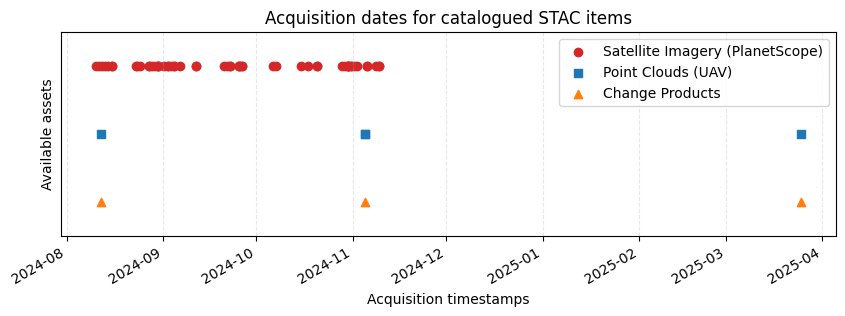

In [ ]:
planet_directory = '../../Documents/isar/'
planet_path = f"{planet_directory}/Isar-AugNov2024-KA_psscene_analytic_8b_sr_udm2_unzip"
catalog_planet = pystac.Catalog.from_file(f"{planet_path}/catalog.json")
#root_catalog.describe()
catalog_planet.describe()
 
timestamps_planet = [item.datetime for item in catalog_planet.get_all_items()]
timestamps_pc = [item.datetime for item in root_catalog.get_all_items()]
 
import matplotlib.pyplot as plt
from datetime import timezone
 
# Normalize datetimes to naive UTC to avoid tz-aware/naive mix issues
def normalize_utc(dts):
    out = []
    for dt in dts:
        if dt is None:
            continue
        out.append(dt.astimezone(timezone.utc).replace(tzinfo=None) if dt.tzinfo else dt)
    return out
 
p = normalize_utc(timestamps_planet)
pc = normalize_utc(timestamps_pc)
m3c2 = pc[1:]
 
fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(p,  [1]*len(p),  color="tab:red",   marker="o", label="Satellite Imagery (PlanetScope)")
ax.scatter(pc, [0]*len(pc), color="tab:blue", marker="s", label="Point Clouds (UAV)")
ax.scatter(m3c2,[ -1]*len(m3c2), color="tab:orange",  marker="^", label="Change Products")
 
ax.set_ylim(-1.5, 1.5)
# ax.set_yticks([-1, 0, 1], ["Change Products", "Point Clouds (UAV)", "Imagery (PlanetScope)"])
ax.set_yticks([])
ax.set_ylabel("Available assets")
ax.set_xlabel("Acquisition timestamps")
ax.grid(True, axis="x", linestyle="--", alpha=0.3)
fig.autofmt_xdate()
ax.legend(loc="best")
#plt.savefig("isar_timestamps.png", dpi=300, bbox_inches="tight")
plt.title("Acquisition dates for catalogued STAC items")
plt.show()

We generated a timeline showing that most PlanetScope images we have locally were acquired between August and November 2024, while our point cloud acquisitions and their M3C2 change products were acquired during an overlapping period of August and November 2024 and March 2025. 

### Loading specific point clouds

The Isar catalog we loaded contains analyzed M3C2 results and processed point clouds and we can see the times their acquisition times in the previous step which are stored as metadata. Their metadata also contain other information such as measurement errors, timezones, and spatial resolutions. 

For our nadir point clouds, their measurement errors differ which propagates to their M3C2 change products. Errors stem from uncertainties in the measurement processes that may have occured due to laser scanning geometries, laser scanner usage, or environmental factors among many other factors.   

Below is an example of a function to load only point clouds with a measurement error below or equal to 0.03 meters. In this case, two processed point clouds are loaded.

In [ ]:
# search by metadata (measurement error)
def measurement_error(acq):
    matches = []
    for item in items:
        if item.properties['topo4d:measurement_error'] <= acq:
            matches.append(item)
        
    return matches


error_search = measurement_error(0.03)
print(error_search)


[<Item id=Isar_m3c2_20240812_20241105>, <Item id=Isar_m3c2_20240812_20250325>]


Here, we acquire their M3C2 product meta, their type, and parameters that were used to process the change analysis product. 

In [ ]:
for item in error_search:
    productmeta = item.properties['topo4d:productmeta']
    #total_files.append((pc_dir + a.href).replace('..',''))
    b = item.datetime

print(productmeta)
print(b)

{'product_name': 'M3C2', 'param': {'param': 0.5}, 'product_level': 'L1'}
2025-03-25 00:00:00+00:00


### References

Lague, Dimitri, et al. “Accurate 3D Comparison of Complex Topography with Terrestrial Laser Scanner: Application to the Rangitikei Canyon (N-Z).” ISPRS Journal of Photogrammetry and Remote Sensing, vol. 82, Aug. 2013, pp. 10–26. DOI.org (Crossref), https://doi.org/10.1016/j.isprsjprs.2013.04.009.
